<a href="https://colab.research.google.com/github/Shibin2000/spotify-etl-pipeline/blob/main/spotifyetl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install  library
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 15.8 MB/s eta 0:00:00


In [3]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')

# Transform
# Select relevant columns, including 'duration_ms' for calculation
df = df[['track_name', 'track_artist', 'track_album_name',
         'track_popularity', 'duration_ms']].copy()

# Calculate 'duration_minutes' from 'duration_ms'
df['duration_minutes'] = round(df['duration_ms'] / 60000, 2)

# Drop the original 'duration_ms' column
df = df.drop(columns=['duration_ms'])

# Rename the remaining columns
df.columns = ['track_name', 'artist', 'album',
              'popularity', 'duration_minutes']

df = df.dropna()

print(f"Loaded and cleaned: {len(df)} songs")
print(df.head())

Loaded and cleaned: 32828 songs
                                          track_name            artist  \
0  I Don't Care (with Justin Bieber) - Loud Luxur...        Ed Sheeran   
1                    Memories - Dillon Francis Remix          Maroon 5   
2                    All the Time - Don Diablo Remix      Zara Larsson   
3                  Call You Mine - Keanu Silva Remix  The Chainsmokers   
4            Someone You Loved - Future Humans Remix     Lewis Capaldi   

                                               album  popularity  \
0  I Don't Care (with Justin Bieber) [Loud Luxury...          66   
1                    Memories (Dillon Francis Remix)          67   
2                    All the Time (Don Diablo Remix)          70   
3                        Call You Mine - The Remixes          60   
4            Someone You Loved (Future Humans Remix)          69   

   duration_minutes  
0              3.25  
1              2.71  
2              2.94  
3              2.82  
4   

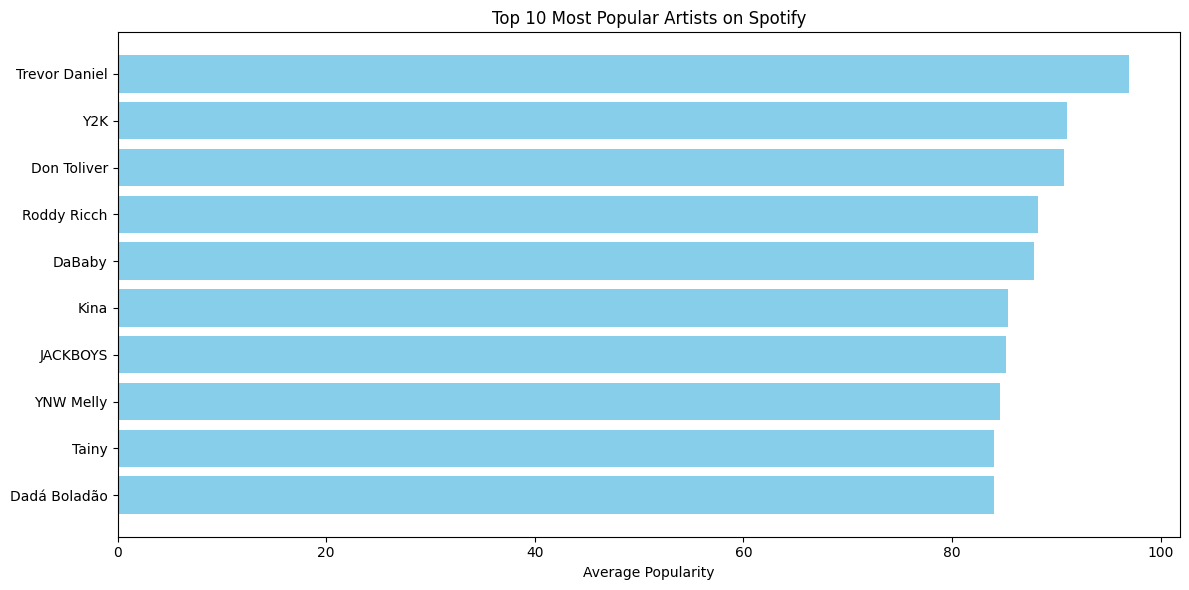

In [4]:
# Visualize top 10 artists
import matplotlib.pyplot as plt

top_artists = df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_artists.index, top_artists.values, color='skyblue')
plt.xlabel('Average Popularity')
plt.title('Top 10 Most Popular Artists on Spotify')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
#  SQL Analysis
popularity_groups = df.copy()

popularity_groups['category'] = popularity_groups['popularity'].apply(
    lambda x: 'Very Popular' if x >= 80
    else ('Popular' if x >= 50 else 'Less Popular')
)

result = popularity_groups.groupby('category')['track_name'].count().reset_index()
result.columns = ['Category', 'Song Count']
print(result)

# Top 1 most popular song
top_song = df.sort_values('popularity', ascending=False).iloc[0]
print(f"\nMost popular song: {top_song['track_name']} by {top_song['artist']}")
print(f"Popularity score: {top_song['popularity']}")

       Category  Song Count
0  Less Popular       18368
1       Popular       12948
2  Very Popular        1512

Most popular song: Dance Monkey by Tones and I
Popularity score: 100


In [7]:
# Save
df.to_csv('spotify_clean.csv', index=False)
print("CSV saved!")

CSV saved!
